<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 122 · Case Study: Predictive Maintenance</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Case Study: Predictive Maintenance</div>
  <div style="font-size:15px;color:#e0e7ff;max-width:740px;line-height:1.6">Predicting machine failure before it happens from raw sensor logs: engineering degradation features (rolling stats, trend, and deviation from each machine's baseline), splitting by machine to avoid leakage, handling a rare failure class, and tuning the threshold so a missed breakdown never slips through. Library-first with scikit-learn, and heavily visual.</div>
  <div style="margin-top:16px;font-size:13px;color:#c7d2fe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# Predictive Maintenance: catching failure before it happens
A machine that fails without warning is expensive: lost production, emergency repairs, missed deadlines. **Predictive maintenance** watches sensor readings and flags a machine likely to fail *soon*, so it can be serviced on schedule. Two ideas make or break this project: **engineering features from the raw signals** (a rising trend and a deviation from the machine's own baseline matter far more than the raw number), and splitting the data **by machine** so the evaluation is honest. Library-first with `scikit-learn`.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, pairplots, count/bar plots)
from matplotlib.colors import ListedColormap
EM="#4338ca"; DEEP="#3730a3"; LIGHT="#c7d2fe"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREEN="#059669"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"; ORG="#4338ca"; CYAN="#0891b2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (average_precision_score, roc_auc_score, recall_score, precision_score,
     accuracy_score, roc_curve, precision_recall_curve, confusion_matrix)
import warnings; warnings.filterwarnings('ignore'); pd.set_option('display.max_columns', 40)

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 1 &#183; DEFINE THE OBJECTIVE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Predict failure early enough to act</div>
<div style="color:#4a5578;margin-top:6px">A missed breakdown dwarfs a needless inspection.</div>
</div>

**The goal.** For each machine, at each moment, predict whether it will **fail within the next 20 operating cycles**, early enough to schedule maintenance in the next window. The costs are asymmetric: a **missed breakdown** (unplanned downtime, secondary damage, idle staff) can run thousands of dollars, while a **needless inspection** costs a few hundred. So, like fraud, this is a rare, high-cost event where we would rather over-warn than miss.

<div style="background:#eef6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">STEP 2 &#183; COLLECT THE DATA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A run-to-failure sensor log</div>
<div style="color:#4a5578;margin-top:6px">One row per machine per cycle.</div>
</div>

In [3]:
try: df = pd.read_csv('../../data/machine_sensors.csv')
except FileNotFoundError: df = pd.read_csv(BASE + 'machine_sensors.csv')
print('raw shape:', df.shape); df.head(4)

raw shape: (27605, 7)


,machine_id,cycle,temperature,vibration,pressure,rpm,failure_within_20
0,M100,1,53.28,1.975,103.73,1496,0
1,M100,2,54.59,2.186,104.54,1504,0
2,M100,3,57.35,1.941,99.75,1500,0
3,M100,4,61.42,0.827,107.24,1476,0


**Time-ordered, grouped data.** Each machine contributes a *sequence* of readings, one row per operating cycle, from installation until it failed. `temperature`, `vibration`, `pressure`, and `rpm` are the raw sensors; `failure_within_20` is 1 if the machine will fail within 20 cycles of that reading. This grouped, time-ordered shape drives two decisions below: how we engineer features, and how we split.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 3 &#183; INSPECT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Fleet size, failure rate, gaps</div>
<div style="color:#4a5578;margin-top:6px">How many machines, how rare is the warning window?</div>
</div>

In [4]:
print('machines:', df.machine_id.nunique(), '| rows:', len(df))
print('cycles per machine: min %d, median %d, max %d' % (df.groupby("machine_id").size().min(), df.groupby("machine_id").size().median(), df.groupby("machine_id").size().max()))
print('failure-window rate: %.1f%%' % (df.failure_within_20.mean()*100))
print('missing temperature reads:', df.temperature.isna().sum(), '| duplicate (machine,cycle):', df.duplicated(["machine_id","cycle"]).sum())

machines: 180 | rows: 27605
cycles per machine: min 70, median 154, max 229
failure-window rate: 13.7%
missing temperature reads: 102 | duplicate (machine,cycle): 20


**A rare, grouped target.** About **14%** of readings sit in a failure window, the minority class, so we will again lean on recall, precision, and PR-AUC rather than accuracy. The data covers 180 machines with widely varying lifetimes, and there are a few dropped sensor reads and duplicate rows to clean.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 4 &#183; CLEAN</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Tidy, in machine-cycle order</div>
<div style="color:#4a5578;margin-top:6px">Dedupe and sort; leave gaps for the pipeline.</div>
</div>

In [5]:
df = df.drop_duplicates(['machine_id','cycle']).sort_values(['machine_id','cycle']).reset_index(drop=True)
print('after dedupe + sort:', df.shape, '| still', '%.1f%%'%(df.failure_within_20.mean()*100), 'in a failure window')

after dedupe + sort: (27585, 7) | still 13.7% in a failure window


**Sorting matters here.** Because we are about to compute rolling and trend features *within each machine over time*, the rows must be sorted by machine and cycle. The few missing temperature reads are left to be median-imputed inside the pipeline (on training data only). No rows are dropped for the target, it is complete.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 5 &#183; VISUALIZE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Watch a machine degrade</div>
<div style="color:#4a5578;margin-top:6px">Sensors drift and then spike as failure nears.</div>
</div>

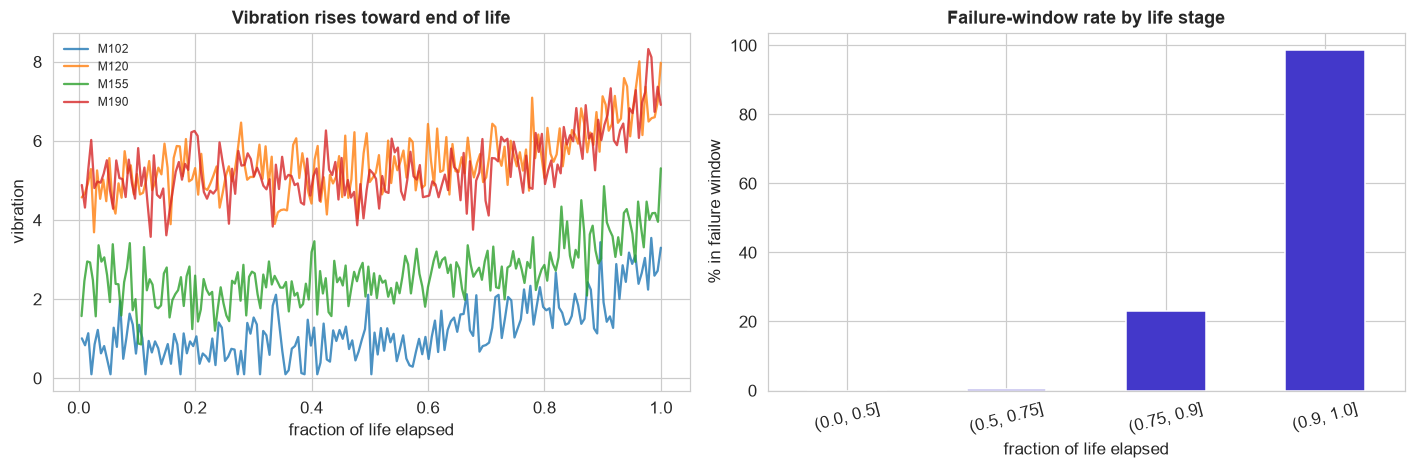

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13,4.4))
sample = df.machine_id.drop_duplicates().iloc[[2,20,55,90]]
for mid in sample:
    m = df[df.machine_id==mid]; life = m.cycle.max()
    ax[0].plot(m.cycle/life, m.vibration, alpha=0.8, label=mid)
ax[0].set(title='Vibration rises toward end of life', xlabel='fraction of life elapsed', ylabel='vibration'); ax[0].legend(fontsize=8)
rate = df.assign(bucket=pd.cut((df.cycle/df.groupby('machine_id').cycle.transform('max')),[0,0.5,0.75,0.9,1.0])).groupby('bucket').failure_within_20.mean()*100
rate.plot.bar(ax=ax[1], color=EM); ax[1].set(title='Failure-window rate by life stage', ylabel='% in failure window', xlabel='fraction of life elapsed'); ax[1].tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()

**Two machines, two baselines.** Plotting vibration against *fraction of life* shows the pattern, readings drift up and then spike as failure nears, but also the trap: each machine sits at a **different baseline**, so a raw vibration of 3.0 might be alarming for one machine and normal for another. That is precisely why the raw number alone is a weak predictor, and why the features we build next matter so much.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 6 &#183; FEATURE ENGINEERING</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Turn raw signals into degradation features</div>
<div style="color:#4a5578;margin-top:6px">The trend and the deviation, not the raw value.</div>
</div>

In [7]:
g = df.groupby('machine_id')
for col in ['temperature','vibration','pressure']:
    df[f'{col}_roll5'] = g[col].transform(lambda s: s.rolling(5, min_periods=1).mean())     # smoothed level
    df[f'{col}_std5']  = g[col].transform(lambda s: s.rolling(5, min_periods=1).std().fillna(0))  # volatility
    df[f'{col}_slope'] = g[col].transform(lambda s: s - s.shift(5)).fillna(0)                # trend over 5 cycles
    df[f'{col}_dev']   = df[col] - g[col].transform(lambda s: s.head(10).mean())             # deviation from THIS machine's baseline
raw_feats = ['temperature','vibration','pressure','rpm','cycle']
eng_feats = raw_feats + [c for c in df.columns if c.endswith(('_roll5','_std5','_slope','_dev'))]
print('raw features:', len(raw_feats), '-> engineered features:', len(eng_feats))
print('new features per sensor: rolling mean, rolling std, slope (trend), deviation from baseline')

raw features: 5 -> engineered features: 17
new features per sensor: rolling mean, rolling std, slope (trend), deviation from baseline


**This is the heart of the chapter.** From each raw sensor we derive four features that capture *how the machine is changing*: a **rolling mean** (smoothed level), a **rolling standard deviation** (is it getting jittery?), a **slope** (the trend over the last five cycles), and, most importantly, a **deviation from the machine's own early-life baseline**. That deviation is what makes a reading comparable across machines with different baselines. Raw sensors describe a snapshot; these features describe a **trajectory**, which is what failure actually is.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 7 &#183; SPLIT BY MACHINE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Never let one machine sit in both train and test</div>
<div style="color:#4a5578;margin-top:6px">A row-wise split leaks, and inflates the score.</div>
</div>

In [8]:
y = df['failure_within_20']; groups = df['machine_id']
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=0)
tr, te = next(gss.split(df, y, groups))
print('GROUP split -> train machines:', df.iloc[tr].machine_id.nunique(), '| test machines:', df.iloc[te].machine_id.nunique(), '(no machine in both)')
# --- why: demonstrate the leak with a naive row-wise split ---
def prauc(Xtr, ytr, Xte, yte):
    p = Pipeline([('i',SimpleImputer(strategy='median')),('c',RandomForestClassifier(n_estimators=250, class_weight='balanced', random_state=0))]).fit(Xtr, ytr)
    return average_precision_score(yte, p.predict_proba(Xte)[:,1])
group_score = prauc(df.iloc[tr][raw_feats], y.iloc[tr], df.iloc[te][raw_feats], y.iloc[te])
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(df[raw_feats], y, test_size=0.25, random_state=0, stratify=y)
row_score = prauc(Xr_tr, yr_tr, Xr_te, yr_te)
print('honest GROUP-split PR-AUC: %.3f' % group_score)
print('naive ROW-split PR-AUC:   %.3f  <- inflated by leakage!' % row_score)

GROUP split -> train machines: 135 | test machines: 45 (no machine in both)


honest GROUP-split PR-AUC: 0.590
naive ROW-split PR-AUC:   0.731  <- inflated by leakage!


**The subtle, expensive mistake.** If we split rows at random, cycle 90 of machine M lands in training while cycle 91 of the *same* machine lands in test, two nearly identical readings. The model effectively memorizes each machine and looks great, then fails on a genuinely new machine in the field. Splitting **by machine** (`GroupShuffleSplit`) is the honest test: every test machine is one the model has never seen. The row-split here scores a flattering **0.73**, the honest group-split a sober **0.59**, that 0.14 gap is pure illusion. We use the group split for everything.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 8 &#183; BUILD: DOES ENGINEERING PAY?</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Raw features vs engineered features</div>
<div style="color:#4a5578;margin-top:6px">Same model, different inputs.</div>
</div>

In [9]:
def evaluate(feats, clf, label):
    pipe = Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler()), ('clf', clf)]).fit(df.iloc[tr][feats], y.iloc[tr])
    prob = pipe.predict_proba(df.iloc[te][feats])[:,1]; pred = pipe.predict(df.iloc[te][feats]); yy = y.iloc[te]
    print(f'{label:32s} PR-AUC {average_precision_score(yy,prob):.3f} | recall {recall_score(yy,pred):.2f} | precision {precision_score(yy,pred):.2f}')
    return pipe, prob
base = DummyClassifier(strategy='most_frequent').fit(df.iloc[tr][raw_feats], y.iloc[tr])
print('baseline accuracy: %.3f (and recall 0)' % accuracy_score(y.iloc[te], base.predict(df.iloc[te][raw_feats])))
evaluate(raw_feats, LogisticRegression(max_iter=2000, class_weight='balanced'), 'RAW features (logistic)')
model, prob = evaluate(eng_feats, LogisticRegression(max_iter=2000, class_weight='balanced'), 'ENGINEERED features (logistic)')
evaluate(eng_feats, RandomForestClassifier(n_estimators=250, class_weight='balanced', random_state=0), 'ENGINEERED features (random forest)')

baseline accuracy: 0.849 (and recall 0)
RAW features (logistic)          PR-AUC 0.613 | recall 0.77 | precision 0.48
ENGINEERED features (logistic)   PR-AUC 0.963 | recall 0.97 | precision 0.76


ENGINEERED features (random forest) PR-AUC 0.874 | recall 0.79 | precision 0.82


(Pipeline(steps=[('impute', SimpleImputer(strategy='median')),
                 ('scale', StandardScaler()),
                 ('clf',
                  RandomForestClassifier(class_weight='balanced',
                                         n_estimators=250, random_state=0))]),
 array([0.008, 0.   , 0.   , ..., 0.968, 0.992, 0.9  ], shape=(6238,)))

**Feature engineering beats model choice.** On the raw sensors, logistic regression manages a mediocre **PR-AUC of 0.61**, the absolute values are too ambiguous across machines. Feed it the *engineered* features and the same model leaps to **0.96**. Swapping in a random forest on those same engineered features actually does a little worse (0.87). The lesson is loud: the biggest lever in this project was not the algorithm, it was **turning raw signals into trajectory features**.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 9 &#183; VALIDATE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Cross-validate by group; read the right curves</div>
<div style="color:#4a5578;margin-top:6px">Confirm it holds across machines.</div>
</div>

GroupKFold CV PR-AUC: 0.959 (+/- 0.006)


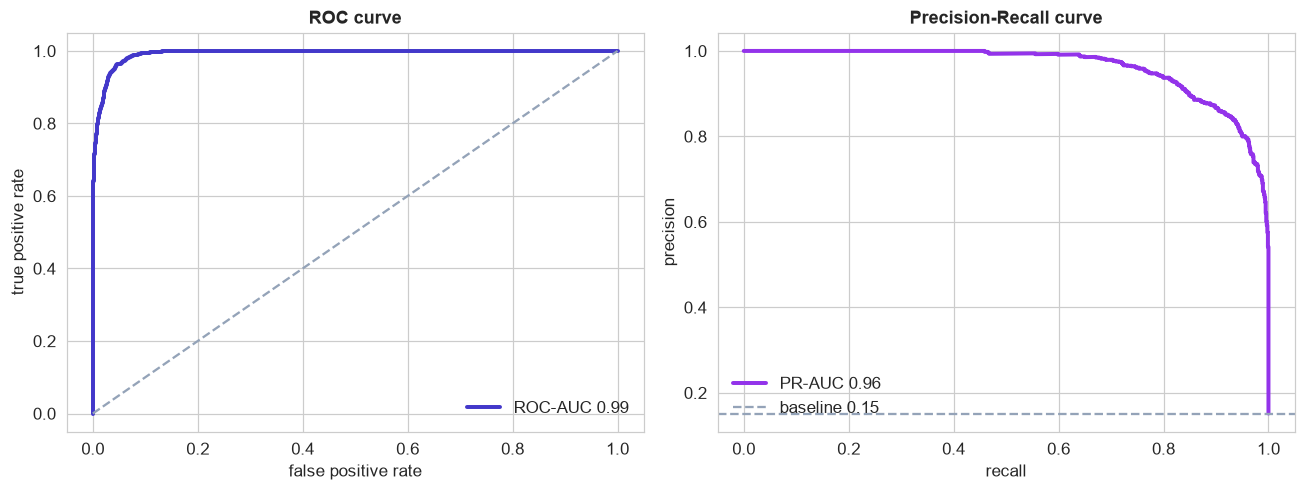

In [10]:
cv = cross_val_score(Pipeline([('i',SimpleImputer(strategy='median')),('s',StandardScaler()),('c',LogisticRegression(max_iter=2000,class_weight='balanced'))]),
     df.iloc[tr][eng_feats], y.iloc[tr], groups=groups.iloc[tr], cv=GroupKFold(5), scoring='average_precision')
print('GroupKFold CV PR-AUC: %.3f (+/- %.3f)' % (cv.mean(), cv.std()))
yy = y.iloc[te]
fig, ax = plt.subplots(1, 2, figsize=(12,4.6))
fpr,tpr,_ = roc_curve(yy, prob); ax[0].plot(fpr,tpr,color=EM,lw=2.6,label=f'ROC-AUC {roc_auc_score(yy,prob):.2f}'); ax[0].plot([0,1],[0,1],'--',color=GREY)
ax[0].set(title='ROC curve', xlabel='false positive rate', ylabel='true positive rate'); ax[0].legend(loc='lower right')
pr,rc,_ = precision_recall_curve(yy, prob); ax[1].plot(rc,pr,color=PUR,lw=2.6,label=f'PR-AUC {average_precision_score(yy,prob):.2f}')
ax[1].axhline(yy.mean(), color=GREY, ls='--', label=f'baseline {yy.mean():.2f}')
ax[1].set(title='Precision-Recall curve', xlabel='recall', ylabel='precision'); ax[1].legend(loc='lower left')
plt.tight_layout(); plt.show()

**It generalizes to unseen machines.** Cross-validating with **GroupKFold** (each fold holds out whole machines) gives a PR-AUC around 0.95, close to the test score, so the result is stable, not a fluke of one split. Because the failure window is the minority class, the **precision-recall curve** is again the honest lens: it sits far above the 0.14 baseline, the model reliably ranks about-to-fail readings above healthy ones.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 10 &#183; THRESHOLD TO COST</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Catch (almost) every failure</div>
<div style="color:#4a5578;margin-top:6px">A missed breakdown is far dearer than an inspection.</div>
</div>

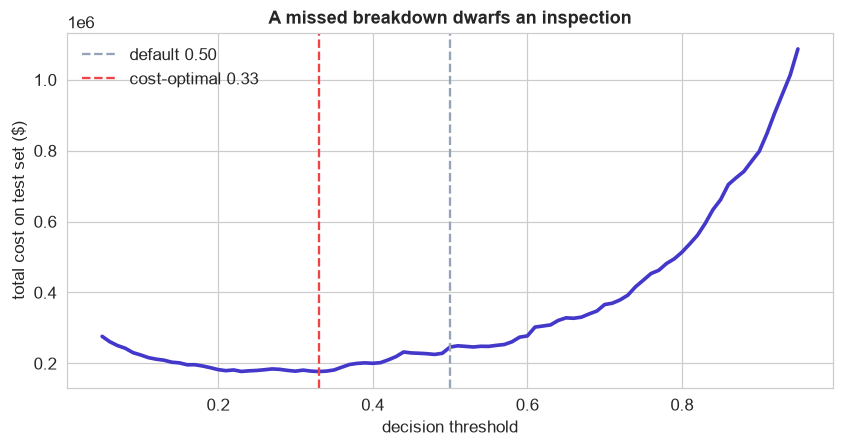

threshold 0.50: recall 0.97 | precision 0.76
threshold 0.33: recall 0.99 | precision 0.70


In [11]:
MISS = 5000     # unplanned breakdown: downtime + secondary damage
INSPECT = 300   # a needless maintenance inspection
yv = y.iloc[te].values; ths = np.linspace(0.05, 0.95, 91)
cost = [((prob<t)&(yv==1)).sum()*MISS + ((prob>=t)&(yv==0)).sum()*INSPECT for t in ths]
best_t = ths[int(np.argmin(cost))]
fig, ax = plt.subplots(figsize=(7.8,4.2))
ax.plot(ths, cost, color=EM, lw=2.4); ax.axvline(0.5, color=GREY, ls='--', label='default 0.50')
ax.axvline(best_t, color=RED, ls='--', label=f'cost-optimal {best_t:.2f}'); ax.set(xlabel='decision threshold', ylabel='total cost on test set ($)', title='A missed breakdown dwarfs an inspection'); ax.legend()
plt.tight_layout(); plt.show()
for t in [0.5, best_t]:
    pp=(prob>=t).astype(int); print(f'threshold {t:.2f}: recall {recall_score(yv,pp):.2f} | precision {precision_score(yv,pp):.2f}')

**Err on the side of caution.** With a breakdown costing many times an inspection, the cost curve pushes the threshold **below 0.5**, we would rather inspect a few healthy machines than miss a failure. At the cost-optimal cutoff the model catches about **99% of impending failures** while keeping false alarms manageable. The threshold is where maintenance policy, not statistics, has the final say.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 11 &#183; INTERPRET</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Which signals warn of failure?</div>
<div style="color:#4a5578;margin-top:6px">The engineered features earn their keep.</div>
</div>

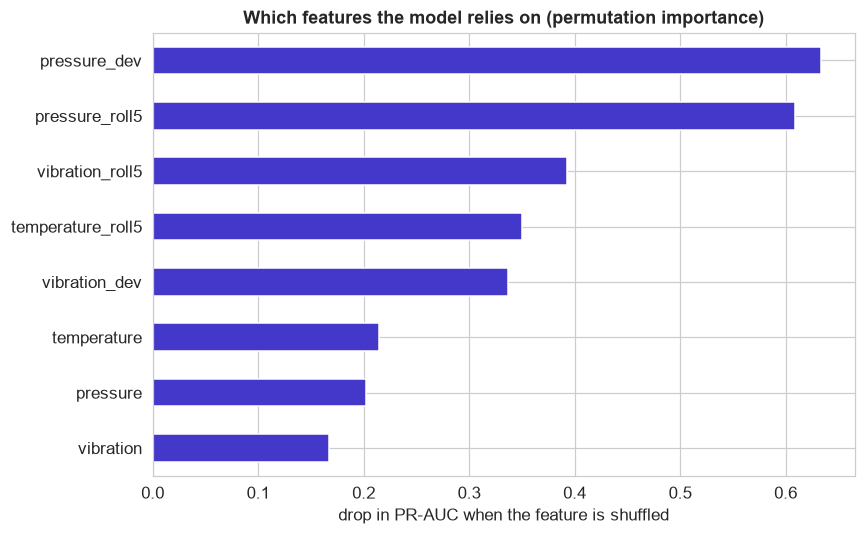

most important features: pressure_dev, pressure_roll5, vibration_roll5, temperature_roll5, vibration_dev


In [12]:
from sklearn.inspection import permutation_importance
pi = permutation_importance(model, df.iloc[te][eng_feats], y.iloc[te], n_repeats=5, random_state=0, scoring='average_precision')
imp = pd.Series(pi.importances_mean, index=eng_feats).sort_values().tail(8)
fig, ax = plt.subplots(figsize=(8,5))
imp.plot.barh(ax=ax, color=EM)
ax.set(title='Which features the model relies on (permutation importance)', xlabel='drop in PR-AUC when the feature is shuffled')
plt.tight_layout(); plt.show()
print('most important features:', ', '.join(imp.index[::-1][:5]))

**The engineered trajectory features dominate.** Permutation importance, how far the model's PR-AUC falls when a single feature is scrambled, puts the **engineered** features on top: the **deviation** of pressure and vibration from each machine's baseline, and the **rolling (smoothed) levels**. The raw snapshot readings barely register on their own. This is the payoff of Step 6 made visible, the model succeeds by tracking each machine's *trajectory*, how far it has drifted from its own normal and how its recent readings are trending, which is exactly how a maintenance engineer thinks.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 12 &#183; DEPLOY ON NEW DATA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Score a machine it has never seen</div>
<div style="color:#4a5578;margin-top:6px">From sensor stream to a maintenance ticket.</div>
</div>

In [13]:
import joblib
DECISION_THRESHOLD = 0.33     # the cost-tuned cutoff from Step 10
joblib.dump(model, 'maintenance_model.joblib')      # the whole pipeline in one file
svc = joblib.load('maintenance_model.joblib')
test = df.iloc[te]
degrading = test[test.failure_within_20==1].iloc[[-1]]     # a held-out machine near failure
healthy   = test[test.failure_within_20==0].iloc[[0]]      # a held-out machine running fine
for label, row in [('degrading machine', degrading), ('healthy machine', healthy)]:
    p = svc.predict_proba(row[eng_feats])[0,1]
    action = 'SCHEDULE MAINTENANCE' if p >= DECISION_THRESHOLD else 'no action, keep monitoring'
    print(f'{label:18s} -> failure-soon probability {p:.2f}  ->  {action}')
print('\nin production: recompute the engineered features from each machine\'s live sensor stream, score every cycle,')
print('open a maintenance ticket when the probability crosses the threshold, and watch for DRIFT as machines age or are replaced.')

degrading machine  -> failure-soon probability 1.00  ->  SCHEDULE MAINTENANCE
healthy machine    -> failure-soon probability 0.00  ->  no action, keep monitoring

in production: recompute the engineered features from each machine's live sensor stream, score every cycle,
open a maintenance ticket when the probability crosses the threshold, and watch for DRIFT as machines age or are replaced.


**From model to maintenance ticket.** The saved pipeline reproduces the exact preprocessing, so scoring a held-out machine is one call: the degrading machine trips the threshold and gets a maintenance ticket, the healthy one is left alone. In production the engineered features are recomputed from each machine's live sensor stream every cycle; when the failure-soon probability crosses the cost-tuned threshold, the system schedules service. As always, monitor for **drift**, new machine models or duty cycles change the baselines, and retrain on fresh run-to-failure data. Chapter 126 covers this lifecycle in full.

## Predictive maintenance, in one view

1. **Engineer features from the raw signals**: rolling mean and std, trend (slope), and deviation from each machine's baseline, this was the biggest lever (PR-AUC 0.61 raw to 0.96 engineered).
2. **Split by machine, not by row**: a row-wise split leaks and inflated PR-AUC from an honest 0.59 to a flattering 0.73.
3. **Judge by precision, recall, and PR-AUC**, the failure window is the rare class; cross-validate with **GroupKFold**.
4. **Tune the threshold to cost**: a missed breakdown dwarfs an inspection, so flag aggressively and catch about 99% of failures.
5. **The warning signs are trajectories**, deviation and trend, not raw values; deploy on each machine's live stream and watch for drift.

**In predictive maintenance, the feature engineering and an honest, group-aware split matter more than the choice of model.**

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>